/var/folders/0g/1st6ryj54n1bshvyq3yt1pzm0000gn/T/ipykernel_80836/2238137536.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load('/Users/zengjian/PyTo


 测试集最终准确率: 94.40%

各癌症类型详细分类报告 (关注小样本的 Recall):
              precision    recall  f1-score   support

         ACC       0.92      0.92      0.92        12
        BLCA       0.98      0.94      0.96        64
        BRCA       1.00      0.98      0.99       183
        CESC       0.85      1.00      0.92        47
        CHOL       0.62      0.83      0.71         6
        COAD       0.75      0.95      0.84        75
        DLBC       1.00      1.00      1.00         7
        ESCA       0.89      0.83      0.86        29
         GBM       1.00      0.88      0.94        26
        HNSC       1.00      1.00      1.00        85
        KICH       0.63      0.92      0.75        13
        KIRC       0.97      0.95      0.96        91
        KIRP       0.93      0.86      0.89        49
        LAML       1.00      1.00      1.00        26
         LGG       0.96      1.00      0.98        80
        LIHC       0.98      0.95      0.97        64
        LUAD       0.92      0.8

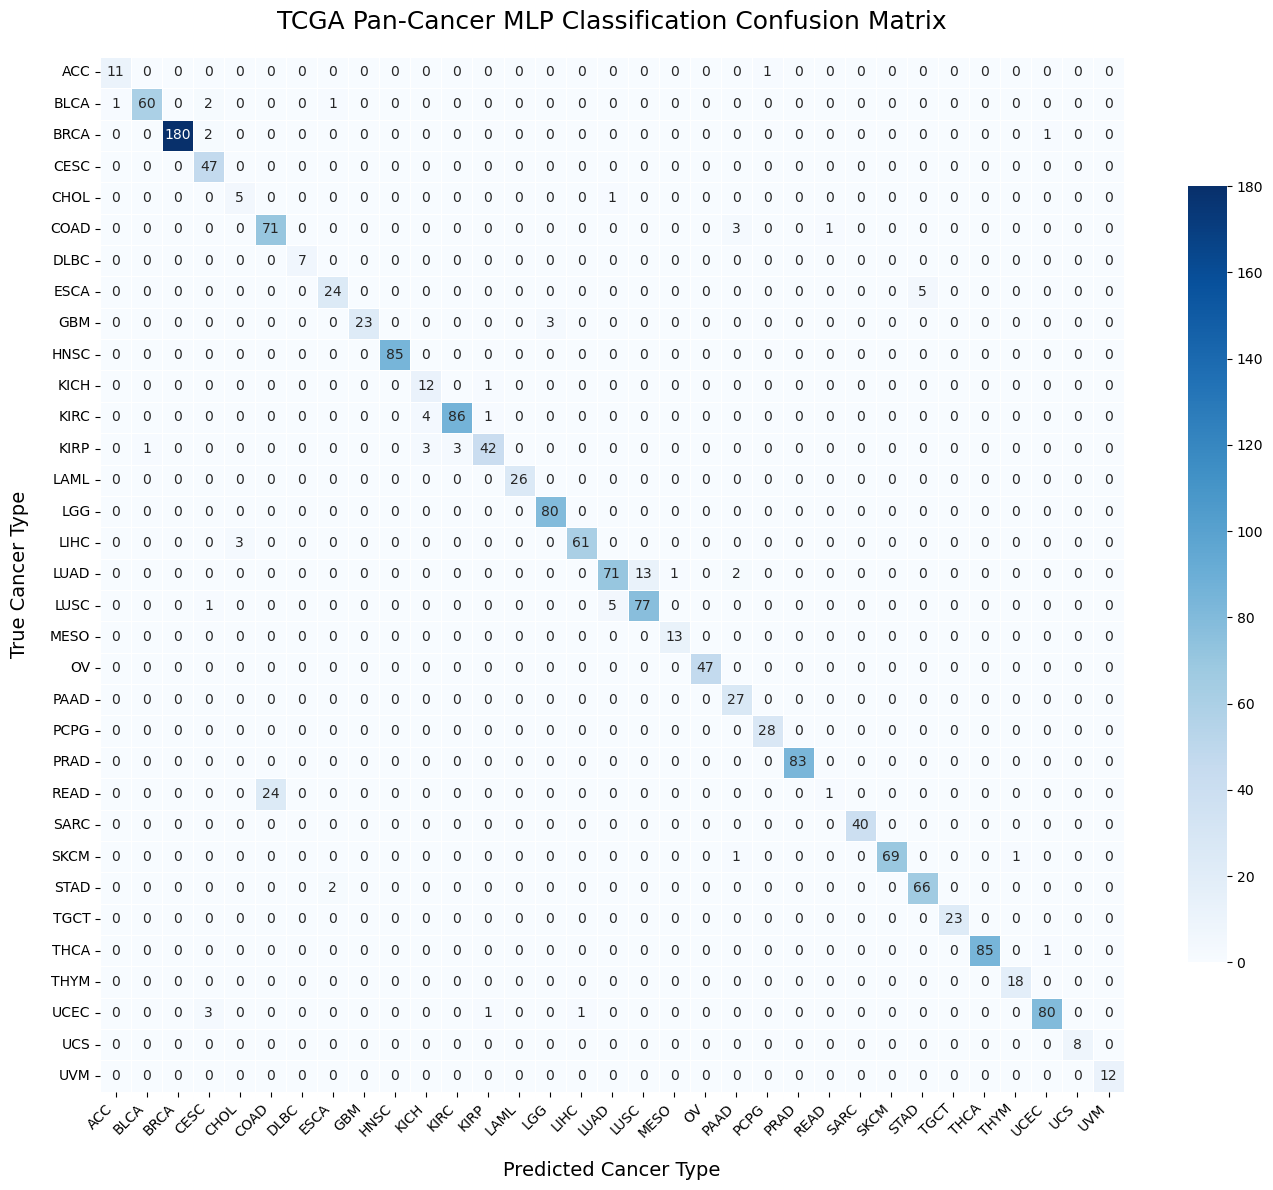

In [19]:

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import joblib
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

data_dict = torch.load('/PyTorch/MLP/data/tcga_processed_tensors.pt')
test_loader = data_dict['test_loader']
num_classes = data_dict['num_classes']
input_dim = data_dict['input_dim']
le = joblib.load('./data/label_encoder.pkl') 
class_names = le.classes_
class TCGA_CancerMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        
        # Linear -> BatchNorm -> ReLU -> Dropout
        self.fc1 = nn.Linear(input_dim, 1024) #全连接层
        self.bn1 = nn.BatchNorm1d(1024) # 批归一化，加速收敛
        self.relu1 = nn.ReLU() # 激活函数
        self.drop1 = nn.Dropout(0.5)    # Dropout 防止过拟合
        
        # 隐藏层 1 到隐藏层 2
        self.fc2 = nn.Linear(1024, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)
        
        # 输出层 (映射到cancer type)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.drop1(self.relu1(self.bn1(self.fc1(x))))
        x = self.drop2(self.relu2(self.bn2(self.fc2(x))))
        x = self.fc3(x) # CrossEntropyLoss 自带 Softmax，这里不需要加
        return x

# 1. 加载最佳模型权重
model = TCGA_CancerMLP(input_dim, num_classes)
model.load_state_dict(torch.load('best_tcga_mlp.pth'))

# 切换到评估模式！
model.eval() 

# 2. 在 Test DataLoader 上进行推理
all_preds = []
all_labels = []
with torch.no_grad(): # 测试阶段不需要计算梯度，极大节省显存并提速
    for batch_x, batch_y in test_loader:        
        # 前向传播得到预测 logits
        outputs = model(batch_x)
        
        # 获取概率最大的那个类别的索引
        _, predicted = torch.max(outputs, 1)
        
        # 将预测结果和真实标签转为 numpy 列表存起来
        all_preds.extend(predicted.numpy())
        all_labels.extend(batch_y.numpy())

# 3. 输出最终评估指标
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = 100 * np.sum(all_preds == all_labels) / len(all_labels)
print(f"\n 测试集最终准确率: {test_acc:.2f}%\n")

# 获取真实的癌症类型名称,不是0，1，2这种数字标签
class_names = le.classes_

print("各癌症类型详细分类报告 (关注小样本的 Recall):")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 4. 绘制混淆矩阵 (Confusion Matrix)

# 计算混淆矩阵的数值
cm = confusion_matrix(all_labels, all_preds)

# 设置画板大小
plt.figure(figsize=(14, 12))

# 使用 Seaborn 绘制热图
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('TCGA Pan-Cancer MLP Classification Confusion Matrix', fontsize=18, pad=20)
plt.xlabel('Predicted Cancer Type', fontsize=14, labelpad=15)
plt.ylabel('True Cancer Type', fontsize=14, labelpad=15)

# 调整刻度标签的角度，防止重叠
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
# 保存图片到本地
plt.savefig('confusion_matrix_tcga.png', dpi=300)
plt.show()